# **Install Requirement**

In [ ]:
!pip install -r "/content/drive/MyDrive/X_Pose_Tracker/requirements.txt"

# **Configure GPU and Mixed Precision TensorFlow**

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print(gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

[]


In [ ]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

# **Import Library**

In [ ]:
import cv2
import mediapipe as mp
import os, time
import json
from collections import Counter
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# **Pre-Processing Data**

## Feature Extraction (Mediapipe Pose)

In [ ]:
# Setup MediaPipe Pose

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [ ]:
# Filename Extraction Function

def extract_subject_name(video_file):
    name = os.path.splitext(video_file)[0]
    parts = name.split("_", 1)
    if len(parts) == 2:
        return parts[1].strip()
    return name.strip()

In [ ]:
# Input folder in Google Drive
dataset_path = "/content/drive/MyDrive/Dataset"
categories = ["Push-Up", "Lunges", "Sit-Up", "Pull-Up"]

# Output folder for Landmarks
output_root = "/content/drive/MyDrive/X_Pose_Tracker/Landmarks"
os.makedirs(output_root, exist_ok=True)

# Standard column for 33 landmark
columns = ["frame_id"] + [
    f"{i}_{axis}"
    for i in range(33)
    for axis in ["x", "y", "z", "visibility"]
]

# Loop category
for category in categories:
    category_path = os.path.join(dataset_path, category)

    if not os.path.exists(category_path):
        print(f"Folder {category} tidak ditemukan, melewati...")
        continue

    # Loop video in kategori
    for video_file in os.listdir(category_path):
        if not video_file.endswith(".mp4"):
            continue

        video_path = os.path.join(category_path, video_file)
        subject_name = extract_subject_name(video_file)

        # Folder subject for output
        subject_out_dir = os.path.join(output_root, subject_name)
        os.makedirs(subject_out_dir, exist_ok=True)

        # Output CSV per subject per category
        output_csv_path = os.path.join(subject_out_dir, f"{category}.csv")

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Gagal membuka {video_file}, melewati...")
            continue

        pose_rows = []
        frame_id = 0

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_id += 1
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(frame_rgb)

            if results.pose_landmarks:
                row = [frame_id]
                for lm in results.pose_landmarks.landmark:
                    row.extend([lm.x, lm.y, lm.z, lm.visibility])
                pose_rows.append(row)

        cap.release()

        # Save CSV per video
        if pose_rows:
            df = pd.DataFrame(pose_rows, columns=columns)
            df.to_csv(output_csv_path, index=False)
            print(f"[OK] {category} - {subject_name} -> {output_csv_path}")
        else:
            print(f"[WARN] Tidak ada landmark terdeteksi pada {video_file}")


[OK] Push-Up - Muhammad Fajri -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Muhammad Fajri/Push-Up.csv
[OK] Push-Up - Muhammad Rifqi -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Muhammad Rifqi/Push-Up.csv
[OK] Push-Up - Nur Alam -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Nur Alam/Push-Up.csv
[OK] Push-Up - Muhammad Fadly -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Muhammad Fadly/Push-Up.csv
[OK] Push-Up - Febriansyah -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Febriansyah/Push-Up.csv
[OK] Push-Up - Haykhal -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Haykhal/Push-Up.csv
[OK] Push-Up - Geraldo Forland -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Geraldo Forland/Push-Up.csv
[OK] Push-Up - Imam B -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Imam B/Push-Up.csv
[OK] Lunges - Haykhal -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Haykhal/Lunges.csv
[OK] Lunges - Imam B -> /content/drive/MyDrive/X_Pose_Tracker/Landmarks/Imam B/Lunges.csv


## Angle Calculation (Dot Product Formula)

In [ ]:
# Angle Calculation Function (2D Based)

def calculate_angle_2d(a, b, c):
    ab = np.array([a[0] - b[0], a[1] - b[1]])
    bc = np.array([c[0] - b[0], c[1] - b[1]])

    dot = np.dot(ab, bc)
    mag_ab = np.linalg.norm(ab)
    mag_bc = np.linalg.norm(bc)

    if mag_ab == 0 or mag_bc == 0:
        return None

    cos_theta = dot / (mag_ab * mag_bc)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    return np.degrees(np.arccos(cos_theta))

In [ ]:
# Angle Calculation Function (3D Based)

def calculate_angle_3d(a, b, c):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)

    ab = a - b
    bc = c - b

    dot = np.dot(ab, bc)
    mag_ab = np.linalg.norm(ab)
    mag_bc = np.linalg.norm(bc)

    if mag_ab == 0 or mag_bc == 0:
        return None

    cos_theta = dot / (mag_ab * mag_bc)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    return np.degrees(np.arccos(cos_theta))

In [ ]:
# Torso Angle Calculation Function

def calculate_torso_angle(mid_hip, mid_shoulder):
    v = np.array(mid_shoulder, dtype=float) - np.array(mid_hip, dtype=float)
    mag_v = np.linalg.norm(v)
    if mag_v == 0:
        return None

    vertical = np.array([0.0, -1.0], dtype=float)
    cos_theta = np.dot(v, vertical) / (mag_v * np.linalg.norm(vertical))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_theta)))

In [ ]:
# 3 Indexes for each angle (12 angles)

JOINTS = {
    # LEFT BODY
    "left_shoulder": [13, 11, 23],
    "left_elbow":    [11, 13, 15],
    "left_wrist":    [13, 15, 19],
    "left_hip":      [11, 23, 25],
    "left_knee":     [23, 25, 27],
    "left_ankle":    [25, 27, 31],

    # RIGHT BODY
    "right_shoulder": [14, 12, 24],
    "right_elbow":    [12, 14, 16],
    "right_wrist":    [14, 16, 20],
    "right_hip":      [12, 24, 26],
    "right_knee":     [24, 26, 28],
    "right_ankle":    [26, 28, 32],
}

In [ ]:
# Angle Calculation

# root landmark
landmark_root = "/content/drive/MyDrive/X_Pose_Tracker/Landmarks"

# root output
output_root_torso = "/content/drive/MyDrive/X_Pose_Tracker/Angles"
output_root_2d    = "/content/drive/MyDrive/X_Pose_Tracker/Angles2D"
output_root_3d    = "/content/drive/MyDrive/X_Pose_Tracker/Angles3D"

os.makedirs(output_root_torso, exist_ok=True)
os.makedirs(output_root_2d, exist_ok=True)
os.makedirs(output_root_3d, exist_ok=True)

subjects = os.listdir(landmark_root)

for subject in subjects:
    subject_path = os.path.join(landmark_root, subject)
    if not os.path.isdir(subject_path):
        continue

    print(f"\n=== Subjek: {subject} ===")

    # Subject folders for each type of output
    out_subj_torso = os.path.join(output_root_torso, subject)
    out_subj_2d    = os.path.join(output_root_2d, subject)
    out_subj_3d    = os.path.join(output_root_3d, subject)

    os.makedirs(out_subj_torso, exist_ok=True)
    os.makedirs(out_subj_2d,    exist_ok=True)
    os.makedirs(out_subj_3d,    exist_ok=True)

    # Loop per movement category (CSV landmark file)
    for file in os.listdir(subject_path):
        if not file.endswith(".csv"):
            continue

        category = file.replace(".csv", "")
        csv_path = os.path.join(subject_path, file)

        df = pd.read_csv(csv_path)

        angle_rows_torso = []
        angle_rows_2d    = []
        angle_rows_3d    = []

        # save the previous angle
        previous_angles_2d = {joint: None for joint in JOINTS}
        previous_angles_3d = {joint: None for joint in JOINTS}
        prev_torso_angle   = None

        # Calculate the angle per-frame
        for _, row in df.iterrows():
            frame_angles_2d  = {}
            frame_angles_3d  = {}

            # Joint Aangle (2D & 3D)
            for joint, (a, b, c) in JOINTS.items():
                # 2D Dataset
                try:
                    a_2d = (row[f"{a}_x"], row[f"{a}_y"])
                    b_2d = (row[f"{b}_x"], row[f"{b}_y"])
                    c_2d = (row[f"{c}_x"], row[f"{c}_y"])
                    angle_2d = calculate_angle_2d(a_2d, b_2d, c_2d)
                except KeyError:
                    angle_2d = None

                if angle_2d is None:
                    opposite = (
                        joint.replace("right", "left")
                        if "right" in joint
                        else joint.replace("left", "right")
                    )
                    angle_2d = previous_angles_2d.get(opposite)
                if angle_2d is None:
                    angle_2d = previous_angles_2d[joint]
                if angle_2d is None:
                    angle_2d = 0.0

                previous_angles_2d[joint] = angle_2d
                frame_angles_2d[joint] = angle_2d

                # 3D Dataset
                try:
                    a_3d = (row[f"{a}_x"], row[f"{a}_y"], row[f"{a}_z"])
                    b_3d = (row[f"{b}_x"], row[f"{b}_y"], row[f"{b}_z"])
                    c_3d = (row[f"{c}_x"], row[f"{c}_y"], row[f"{c}_z"])
                    angle_3d = calculate_angle_3d(a_3d, b_3d, c_3d)
                except KeyError:
                    angle_3d = None

                if angle_3d is None:
                    opposite = (
                        joint.replace("right", "left")
                        if "right" in joint
                        else joint.replace("left", "right")
                    )
                    angle_3d = previous_angles_3d.get(opposite)
                if angle_3d is None:
                    angle_3d = previous_angles_3d[joint]
                if angle_3d is None:
                    angle_3d = 0.0

                previous_angles_3d[joint] = angle_3d
                frame_angles_3d[joint] = angle_3d

            # Torso Angle
            torso_angle = None
            try:
                # left and right shoulders (11,12) and left and right hips (23,24)
                ls = np.array([row["11_x"], row["11_y"]], dtype=float)
                rs = np.array([row["12_x"], row["12_y"]], dtype=float)
                lh = np.array([row["23_x"], row["23_y"]], dtype=float)
                rh = np.array([row["24_x"], row["24_y"]], dtype=float)

                # Center point of shoulders & hips
                mid_shoulder = (ls + rs) / 2.0
                mid_hip      = (lh + rh) / 2.0

                # Torso angle: torso vector vs vertical axis
                torso_angle = calculate_torso_angle(mid_hip, mid_shoulder)

            except KeyError:
                torso_angle = None

            # fallback as before (to maintain stability)
            if torso_angle is None:
                torso_angle = prev_torso_angle
            if torso_angle is None:
                torso_angle = 0.0

            prev_torso_angle = torso_angle

            # Save a row for each output type
            # 2D
            angle_rows_2d.append(frame_angles_2d)

            # 3D
            angle_rows_3d.append(frame_angles_3d)

            # 2D + torso
            frame_torso = dict(frame_angles_2d)
            frame_torso["torso_angle"] = torso_angle
            angle_rows_torso.append(frame_torso)

        # Save CSV for subject + category
        df_torso = pd.DataFrame(angle_rows_torso)
        df_2d    = pd.DataFrame(angle_rows_2d)
        df_3d    = pd.DataFrame(angle_rows_3d)

        out_csv_torso = os.path.join(out_subj_torso, f"{category}_angles.csv")
        out_csv_2d    = os.path.join(out_subj_2d,    f"{category}_angles2d.csv")
        out_csv_3d    = os.path.join(out_subj_3d,    f"{category}_angles3d.csv")

        df_torso.to_csv(out_csv_torso, index=False)
        df_2d.to_csv(out_csv_2d,       index=False)
        df_3d.to_csv(out_csv_3d,       index=False)

        print(f"[OK] {category} →")
        print(f"     Angles (2D+torso): {out_csv_torso}")
        print(f"     Angles2D         : {out_csv_2d}")
        print(f"     Angles3D         : {out_csv_3d}")

print("\nSelesai! Semua sudut 2D, 3D, dan torso telah dihitung untuk seluruh subject.")


=== Subjek: Muhammad Fajri ===
[OK] Push-Up →
     Angles (2D+torso): /content/drive/MyDrive/X_Pose_Tracker/Angles/Muhammad Fajri/Push-Up_angles.csv
     Angles2D         : /content/drive/MyDrive/X_Pose_Tracker/Angles2D/Muhammad Fajri/Push-Up_angles2d.csv
     Angles3D         : /content/drive/MyDrive/X_Pose_Tracker/Angles3D/Muhammad Fajri/Push-Up_angles3d.csv
[OK] Lunges →
     Angles (2D+torso): /content/drive/MyDrive/X_Pose_Tracker/Angles/Muhammad Fajri/Lunges_angles.csv
     Angles2D         : /content/drive/MyDrive/X_Pose_Tracker/Angles2D/Muhammad Fajri/Lunges_angles2d.csv
     Angles3D         : /content/drive/MyDrive/X_Pose_Tracker/Angles3D/Muhammad Fajri/Lunges_angles3d.csv
[OK] Sit-Up →
     Angles (2D+torso): /content/drive/MyDrive/X_Pose_Tracker/Angles/Muhammad Fajri/Sit-Up_angles.csv
     Angles2D         : /content/drive/MyDrive/X_Pose_Tracker/Angles2D/Muhammad Fajri/Sit-Up_angles2d.csv
     Angles3D         : /content/drive/MyDrive/X_Pose_Tracker/Angles3D/Muhammad Fajri/

## Display Data Statitics

In [ ]:
# Display Statistics Dataset Function

def compute_angle_statistics(root_folder, suffix=".csv"):
    all_rows = []

    for subject in os.listdir(root_folder):
        subject_path = os.path.join(root_folder, subject)
        if not os.path.isdir(subject_path):
            continue

        for file in os.listdir(subject_path):
            if not file.endswith(suffix):
                continue

            category = file.replace(suffix, "")
            csv_path = os.path.join(subject_path, file)

            try:
                df = pd.read_csv(csv_path)
            except Exception as e:
                print(f"[ERROR] Tidak bisa baca file {csv_path}: {e}")
                continue

            df["subject"] = subject
            df["category"] = category

            all_rows.append(df)

    if len(all_rows) == 0:
        print(f"[WARNING] Tidak ada file dengan suffix '{suffix}' ditemukan di folder {root_folder}")
        return None, None, None

    Angles_df = pd.concat(all_rows, ignore_index=True)

    angle_columns = [
        c for c in Angles_df.columns
        if c not in ["subject", "category"]
    ]

    stats_overall = Angles_df[angle_columns].describe().T
    stats_overall["range"] = stats_overall["max"] - stats_overall["min"]

    print("\n===== S T A T I S T I K  G L O B A L =====")
    print(stats_overall)

    return Angles_df, stats_overall, angle_columns

In [ ]:
# Statistics 2D Dataset

angles_2d_root = "/content/drive/MyDrive/X_Pose_Tracker/Angles2D"
Angles2D_df, stats2D, cols2D = compute_angle_statistics(
    angles_2d_root,
    suffix="_angles2d.csv"
)


===== S T A T I S T I K  G L O B A L =====
                  count        mean        std        min         25%  \
left_shoulder   14043.0   72.054780  56.455976   0.011782   19.821280   
left_elbow      14043.0  111.035151  50.926793   0.040157   58.061153   
left_wrist      14043.0  150.446634  26.302240   0.450046  137.060665   
left_hip        14043.0  137.886120  48.919883   3.250741  115.585198   
left_knee       14043.0  125.239615  53.426823  11.540786   67.898458   
left_ankle      14043.0  124.864768  27.657242   1.008936  105.364363   
right_shoulder  14043.0   69.094328  57.274602   0.005539   16.476607   
right_elbow     14043.0  114.004932  49.967428   1.122990   64.691111   
right_wrist     14043.0  151.481799  24.327917   0.828261  141.052809   
right_hip       14043.0  136.695131  48.890243   7.395308  113.560405   
right_knee      14043.0  125.313367  51.980781   4.411389   72.522088   
right_ankle     14043.0  124.826359  26.553134  21.814545  107.284097   

      

In [ ]:
# Statistics 3D Dataset

angles_3d_root = "/content/drive/MyDrive/X_Pose_Tracker/Angles3D"
Angles3D_df, stats3D, cols3D = compute_angle_statistics(
    angles_3d_root,
    suffix="_angles3d.csv"
)


===== S T A T I S T I K  G L O B A L =====
                  count        mean        std        min         25%  \
left_shoulder   14043.0   80.389010  42.993226   0.266277   47.266228   
left_elbow      14043.0  115.633238  34.329692  11.045302   92.972411   
left_wrist      14043.0  136.937593  23.038993  13.780067  120.614972   
left_hip        14043.0  129.745441  43.306044   3.277006  111.978971   
left_knee       14043.0  113.834103  46.300574  21.932824   66.541060   
left_ankle      14043.0   97.132624  22.943122  14.704411   81.757070   
right_shoulder  14043.0   81.713209  41.820721   0.556630   50.471390   
right_elbow     14043.0  122.664133  29.265712   8.434302  106.610696   
right_wrist     14043.0  139.710094  24.877988  15.281357  122.258448   
right_hip       14043.0  130.819415  43.136883   9.615948  112.343317   
right_knee      14043.0  112.950598  45.367626   5.137618   69.011230   
right_ankle     14043.0   98.204470  23.296637  35.901048   80.822067   

      

In [ ]:
# Statistics 2D Dataset + Torso

angles_root = "/content/drive/MyDrive/X_Pose_Tracker/Angles"
Angles_df, stats, cols = compute_angle_statistics(
    angles_root,
    suffix="_angles.csv"
)


===== S T A T I S T I K  G L O B A L =====
                  count        mean        std        min         25%  \
left_shoulder   14043.0   72.054780  56.455976   0.011782   19.821280   
left_elbow      14043.0  111.035151  50.926793   0.040157   58.061153   
left_wrist      14043.0  150.446634  26.302240   0.450046  137.060665   
left_hip        14043.0  137.886120  48.919883   3.250741  115.585198   
left_knee       14043.0  125.239615  53.426823  11.540786   67.898458   
left_ankle      14043.0  124.864768  27.657242   1.008936  105.364363   
right_shoulder  14043.0   69.094328  57.274602   0.005539   16.476607   
right_elbow     14043.0  114.004932  49.967428   1.122990   64.691111   
right_wrist     14043.0  151.481799  24.327917   0.828261  141.052809   
right_hip       14043.0  136.695131  48.890243   7.395308  113.560405   
right_knee      14043.0  125.313367  51.980781   4.411389   72.522088   
right_ankle     14043.0  124.826359  26.553134  21.814545  107.284097   
torso_a

## Display The Amount of Data (Number of Frames)

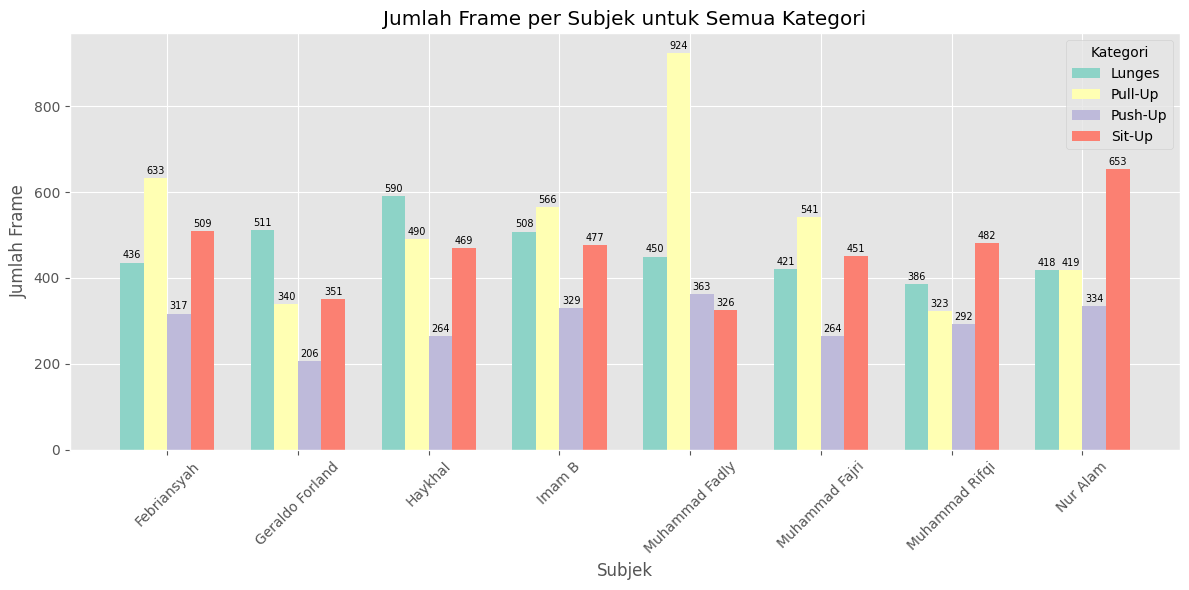

In [ ]:
# Display The Amount of Data

ANGLE_ROOT = "/content/drive/MyDrive/X_Pose_Tracker/Angles"

categories_subject_count = {}

for subject in os.listdir(ANGLE_ROOT):
    subject_path = os.path.join(ANGLE_ROOT, subject)
    if not os.path.isdir(subject_path):
        continue

    for file in os.listdir(subject_path):
        if file.endswith("_angles.csv"):
            category = file.replace("_angles.csv", "")
            df = pd.read_csv(os.path.join(subject_path, file))

            if category not in categories_subject_count:
                categories_subject_count[category] = {}

            categories_subject_count[category][subject] = len(df)

plt.style.use("ggplot")
plt.figure(figsize=(12, 6))

categories = sorted(categories_subject_count.keys())
subjects = sorted({sub for cat in categories for sub in categories_subject_count[cat].keys()})
x = np.arange(len(subjects))

bar_width = 0.18
cmap = plt.get_cmap("Set3")
colors = cmap(range(len(categories)))

for i, category in enumerate(categories):
    counts = [categories_subject_count[category].get(sub, 0) for sub in subjects]

    plt.bar(x + i * bar_width, counts, width=bar_width, label=category, color=colors[i])

    for xi, h in zip(x + i * bar_width, counts):
        plt.text(xi, h + 5, str(h), ha='center', va='bottom', fontsize=7)

# Visualization
plt.xticks(x + bar_width * (len(categories) - 1) / 2, subjects, rotation=45)
plt.xlabel("Subjek")
plt.ylabel("Jumlah Frame")
plt.title("Jumlah Frame per Subjek untuk Semua Kategori")
plt.legend(title="Kategori")
plt.tight_layout()

plt.show()

## Display Distribution of Data

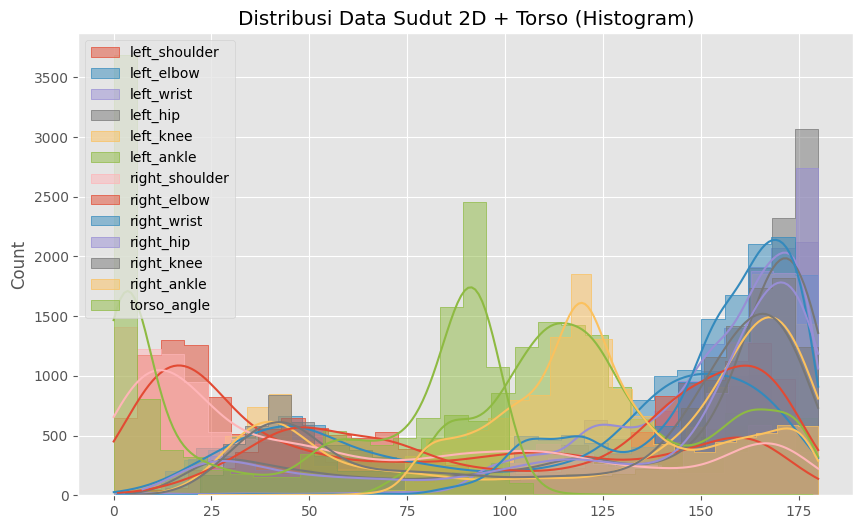

In [ ]:
# 2D with Torso Dataset Distribution

Angles_df.drop(columns=["subject", "category"], inplace=True)

# Visualization
plt.figure(figsize=(10, 6))
for col in Angles_df.columns:
  sns.histplot(Angles_df[col], kde=True, label=col, bins=100, element='step')
plt.title('Distribusi Data Sudut 2D + Torso (Histogram)')
plt.xlabel(None)
plt.legend()
plt.show()

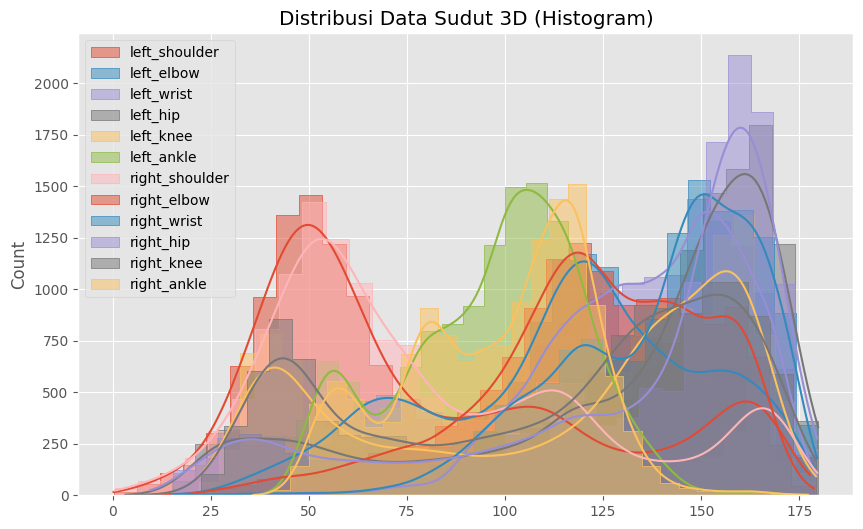

In [ ]:
# 3D Dataset Distribution

Angles3D_df.drop(columns=["subject", "category"], inplace=True)

# Visualization
plt.figure(figsize=(10, 6))
for col in Angles3D_df.columns:
  sns.histplot(Angles3D_df[col], kde=True, label=col, bins=100, element='step')
plt.title('Distribusi Data Sudut 3D (Histogram)')
plt.xlabel(None)
plt.legend()
plt.show()

## Sequence Extraction (Overlapping Sliding Window)

In [ ]:
# Overlapping Sliding window function

def sliding_window(df, label, frame_per_sample, stride):
    features = df.values
    X, y = [], []

    for i in range(0, len(df) - frame_per_sample + 1, stride):
        window = features[i:i + frame_per_sample]
        X.append(window)
        y.append(label)

    return X, y

In [ ]:
# Sequence Extraction Function

def load_data(angle_root, frame_per_sample, stride, file_suffix="_angles.csv"):
    subjects = [
        s for s in os.listdir(angle_root)
        if os.path.isdir(os.path.join(angle_root, s))
    ]

    all_labels = []
    subject_files = {}

    # Collect all file per subject
    for subject in subjects:
        subject_path = os.path.join(angle_root, subject)
        files = []

        for file in os.listdir(subject_path):
            if not file.endswith(file_suffix):
                continue

            label_str = file.replace(file_suffix, "")
            csv_path = os.path.join(subject_path, file)

            files.append((csv_path, label_str))
            all_labels.append(label_str)

        subject_files[subject] = files

    # Encode labels
    le = LabelEncoder()
    le.fit(sorted(set(all_labels)))
    label_map = {lab: idx for idx, lab in enumerate(le.classes_)}

    # Sequence segmentation per subject
    subject_Xy = {}

    for subject, files in subject_files.items():
        X_sub, y_sub = [], []

        for csv_path, label_str in files:
            df = pd.read_csv(csv_path)

            df = df.drop(columns=["label"], errors="ignore")

            X_part, y_part = sliding_window(
                df,
                label_map[label_str],
                frame_per_sample,
                stride
            )

            X_sub.extend(X_part)
            y_sub.extend(y_part)

        subject_Xy[subject] = (np.array(X_sub), np.array(y_sub))

    return subject_Xy, le

In [ ]:
# Argument for Sliding Window

frame_per_sample = 30
stride = 10

In [ ]:
# 2D Dataset with Torso

ANGLE_ROOT = "/content/drive/MyDrive/X_Pose_Tracker/Angles"
subject_Xy, le = load_data(
    ANGLE_ROOT,
    frame_per_sample=frame_per_sample,
    stride=stride,
    file_suffix="_angles.csv"
)
print("Label (Angles):", le.classes_)
for s, (X_s, y_s) in subject_Xy.items():
    print(f"{s}: X={X_s.shape}, y={y_s.shape}")


Label (Angles): ['Lunges' 'Pull-Up' 'Push-Up' 'Sit-Up']
Muhammad Fajri: X=(159, 30, 13), y=(159,)
Muhammad Rifqi: X=(139, 30, 13), y=(139,)
Nur Alam: X=(172, 30, 13), y=(172,)
Muhammad Fadly: X=(197, 30, 13), y=(197,)
Febriansyah: X=(179, 30, 13), y=(179,)
Haykhal: X=(172, 30, 13), y=(172,)
Geraldo Forland: X=(132, 30, 13), y=(132,)
Imam B: X=(177, 30, 13), y=(177,)


In [ ]:
# 2D Dataset

ANGLE_2D_ROOT = "/content/drive/MyDrive/X_Pose_Tracker/Angles2D"
subject_Xy_2d, le_2d = load_data(
    ANGLE_2D_ROOT,
    frame_per_sample=frame_per_sample,
    stride=stride,
    file_suffix="_angles2d.csv"
)
print("\nLabel (2D):", le_2d.classes_)
for s, (X_s, y_s) in subject_Xy_2d.items():
    print(f"{s}: X={X_s.shape}, y={y_s.shape}")


Label (2D): ['Lunges' 'Pull-Up' 'Push-Up' 'Sit-Up']
Muhammad Fajri: X=(159, 30, 12), y=(159,)
Muhammad Rifqi: X=(139, 30, 12), y=(139,)
Nur Alam: X=(172, 30, 12), y=(172,)
Muhammad Fadly: X=(197, 30, 12), y=(197,)
Febriansyah: X=(179, 30, 12), y=(179,)
Haykhal: X=(172, 30, 12), y=(172,)
Geraldo Forland: X=(132, 30, 12), y=(132,)
Imam B: X=(177, 30, 12), y=(177,)


In [ ]:
# 3D Dataset

ANGLE_3D_ROOT = "/content/drive/MyDrive/X_Pose_Tracker/Angles3D"
subject_Xy_3d, le_3d = load_data(
    ANGLE_3D_ROOT,
    frame_per_sample=frame_per_sample,
    stride=stride,
    file_suffix="_angles3d.csv"
)
print("\nLabel (3D):", le_3d.classes_)
for s, (X_s, y_s) in subject_Xy_3d.items():
    print(f"{s}: X={X_s.shape}, y={y_s.shape}")


Label (3D): ['Lunges' 'Pull-Up' 'Push-Up' 'Sit-Up']
Muhammad Fajri: X=(159, 30, 12), y=(159,)
Muhammad Rifqi: X=(139, 30, 12), y=(139,)
Nur Alam: X=(172, 30, 12), y=(172,)
Muhammad Fadly: X=(197, 30, 12), y=(197,)
Febriansyah: X=(179, 30, 12), y=(179,)
Haykhal: X=(172, 30, 12), y=(172,)
Geraldo Forland: X=(132, 30, 12), y=(132,)
Imam B: X=(177, 30, 12), y=(177,)


## Display The Amount of Data (Number of Sequences)

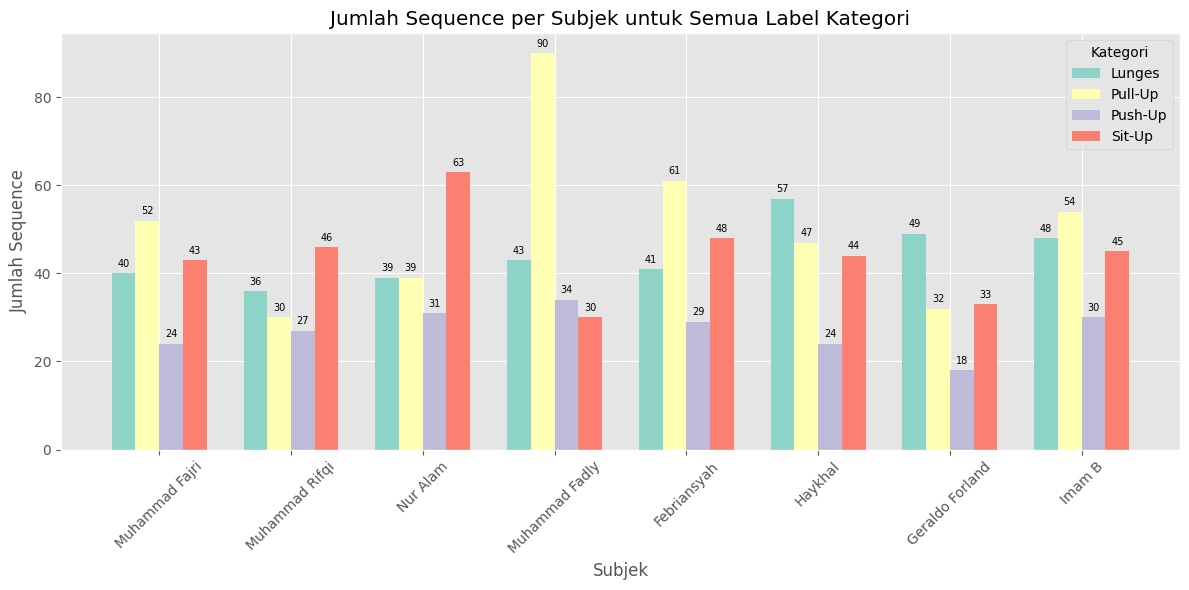

In [ ]:
# Display Data

subjects = list(subject_Xy.keys())
label_names = list(le.classes_)
num_labels = len(label_names)

# Count the number of sequences per subject per label
counts = {lab: [] for lab in label_names}

for subject in subjects:
    X_sub, y_sub = subject_Xy[subject]
    for lab_idx, lab_name in enumerate(label_names):
        n_seq_lab = int(np.sum(y_sub == lab_idx))
        counts[lab_name].append(n_seq_lab)

plt.style.use("ggplot")
plt.figure(figsize=(12, 6))

x = np.arange(len(subjects))
bar_width = 0.18

cmap = plt.get_cmap("Set3")
colors = cmap(range(num_labels))

for i, lab_name in enumerate(label_names):
    values = counts[lab_name]

    # bar position
    plt.bar(x + i * bar_width, values, width=bar_width, label=lab_name, color=colors[i])

    # number on the bar
    for xi, h in zip(x + i * bar_width, values):
        plt.text(xi, h + 1, str(h), ha="center", va="bottom", fontsize=7)

# Visualization
plt.xticks(x + bar_width * (num_labels - 1) / 2, subjects, rotation=45)
plt.xlabel("Subjek")
plt.ylabel("Jumlah Sequence")
plt.title("Jumlah Sequence per Subjek untuk Semua Label Kategori")
plt.legend(title="Kategori")

plt.tight_layout()
plt.show()

# **Training Model using Leave-One-Subject-Out (LOSO) Cross-Validation**

## Setup

In [ ]:
# TensorFlow Dataset Pipeline Builder

def make_dataset(X, y_oh, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y_oh))
    if training:
        ds = ds.shuffle(min(len(X), 3000), reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
# Feature Standardization Utilities (Z-score)

def fit_standardize_train_only(X_train):
    flat = X_train.reshape(-1, X_train.shape[-1])
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0) + 1e-8
    return mean, std

def apply_standardize(X, mean, std):
    flat = X.reshape(-1, X.shape[-1])
    flat = (flat - mean) / std
    return flat.reshape(X.shape)

In [ ]:
# Concatenate Subject Data

def concat_subjects(subject_Xy, subject_list):
    Xs, ys = [], []
    for s in subject_list:
        X, y = subject_Xy[s]
        Xs.append(X)
        ys.append(y)
    return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0)

In [ ]:
# Undersampling Function

def undersample_per_class_mean(
    X,
    y,
    min_cap=250,
    round_to=10,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    X = np.asarray(X)

    class_counts = Counter(y)
    counts = np.array(list(class_counts.values()))

    # Set Cap Using Mean Train Dataset
    cap = int(np.ceil(np.mean(counts)))

    # Round Data after Undersampling
    if round_to > 1:
        cap = int(np.ceil(cap / round_to) * round_to)

    cap = max(cap, min_cap)

    selected_idx = []

    for cls, cls_count in class_counts.items():
        idx = np.where(y == cls)[0]

        # Skip Undersampling if Data is Less
        if cls_count <= cap:
            selected_idx.extend(idx)
        # Undersampling
        else:
            chosen = rng.choice(idx, size=cap, replace=False)
            selected_idx.extend(chosen)

    selected_idx = np.array(selected_idx)
    rng.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx]

## Build Model for Hyperparameter Tuning

### **BiLSTM 1 Layer**

In [ ]:
# Build Hyperparameter Tuning BiLSTM 1 Layer

def build_tunable_bilstm(
    hp,
    input_shape,
    num_classes,
    learning_rate
):
    # LSTM Layer 1
    lstm_units    = hp.Choice("lstm_units", [32, 64, 128])
    dropout_lstm  = hp.Float("dropout_lstm", 0.1, 0.5, step=0.1)

    # Dense
    dense_units   = hp.Choice("dense_units", [32, 64, 128])
    dropout_dense = hp.Float("dropout_dense", 0.1, 0.5, step=0.1)

    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Bidirectional Layer
        layers.Bidirectional(
            layers.LSTM(
                units=lstm_units,
                return_sequences=False
            )
        ),
        layers.Dropout(dropout_lstm),

        # Dense Layer
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout_dense),

        # Output Layer
        layers.Dense(num_classes, activation="softmax", dtype="float32")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### **BiLSTM 2 Layer**

In [ ]:
# Build Hyperparameter Tuning BiLSTM 2 Layer

def build_tunable_bilstm_2layer(
    hp,
    input_shape,
    num_classes,
    learning_rate
):
    # LSTM Layer 1
    lstm_units_l1   = hp.Choice("lstm_units_l1", [32, 64, 128])
    dropout_lstm_l1 = hp.Float("dropout_lstm_l1", 0.1, 0.5, step=0.1)

    # LSTM Layer 2
    lstm_units_l2   = hp.Choice("lstm_units_l2", [32, 64, 128])
    dropout_lstm_l2 = hp.Float("dropout_lstm_l2", 0.1, 0.5, step=0.1)

    # Dense
    dense_units     = hp.Choice("dense_units", [32, 64, 128])
    dropout_dense   = hp.Float("dropout_dense", 0.1, 0.5, step=0.1)

    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # BiLSTM Layer 1
        layers.Bidirectional(
            layers.LSTM(
                units=lstm_units_l1,
                return_sequences=True
            )
        ),
        layers.Dropout(dropout_lstm_l1),

        # BiLSTM Layer 2
        layers.Bidirectional(
            layers.LSTM(
                units=lstm_units_l2,
                return_sequences=False
            )
        ),
        layers.Dropout(dropout_lstm_l2),

        # Dense Layer
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout_dense),

        # Output Layer
        layers.Dense(num_classes, activation="softmax", dtype="float32")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### **Run Hyperparameter Tuning**

In [ ]:
# Hyperparameter Tuning BiLSTM

def run_hpt_loso(
    subject_Xy,
    le,
    scenario_name,
    batch_size_tune,
    max_trials,
    learning_rate,
    tuner_root="/content/drive/MyDrive/X_Pose_Tracker/Tuner_Keras"
):
    num_classes = len(le.classes_)

    val_subject = "Geraldo Forland"

    # Split Subject (Train & Val Dataset)
    train_subjects = [
        s for s in subject_Xy.keys()
        if s != val_subject
    ]

    X_train, y_train = concat_subjects(subject_Xy, train_subjects)
    X_val,   y_val   = subject_Xy[val_subject]

    # Undersampling Train Dataset
    X_train, y_train = undersample_per_class_mean(
        X_train,
        y_train,
        min_cap=250,
        round_to=10,
        random_state=42
    )

    # Encoding Label (One Hot Encoder)
    y_train_oh = keras.utils.to_categorical(y_train, num_classes)
    y_val_oh   = keras.utils.to_categorical(y_val,   num_classes)

    # Standardization Z-score (Apply to train and val dataset)
    mean, std = fit_standardize_train_only(X_train)
    X_train = apply_standardize(X_train, mean, std)
    X_val   = apply_standardize(X_val,   mean, std)

    input_shape = X_train.shape[1:]

    # Make Dataset to Model (Train & Val)
    train_ds = make_dataset(
        X_train, y_train_oh,
        batch_size=batch_size_tune,
        training=True
    )
    val_ds = make_dataset(
        X_val, y_val_oh,
        batch_size=batch_size_tune,
        training=False
    )

    # Deploy Tuner using Bayesian Optimization
    tuner = kt.BayesianOptimization(
        # Change model depend on the Num of layer
        hypermodel=lambda hp: build_tunable_bilstm_2layer(
            hp,
            input_shape=input_shape,
            num_classes=num_classes,
            learning_rate=learning_rate
        ),

        objective="val_accuracy",
        max_trials=max_trials,
        directory=os.path.join(tuner_root, f"{scenario_name}"),
        project_name="bilstm_hpt",
        overwrite=True
    )

    # Searching Best Hyperparameter
    tuner.search(
        train_ds,
        epochs=30,
        validation_data=val_ds,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=1
    )

    # Get Best Hyperparameter
    best_hp = tuner.get_best_hyperparameters(1)[0]

    print(f"\n=== Best HP (Val Subject: {val_subject}) ===")
    for k, v in best_hp.values.items():
        print(f"{k}: {v}")

    return best_hp

## Build Model for Training Model

### **BiLSTM 1 Layer**

In [ ]:
# Build Model BiLSTM 1 Layer

def build_bilstm_from_hp(
    best_hp,
    input_shape,
    num_classes,
    learning_rate
):
    model = keras.Sequential([
        # Input Layer
        layers.Input(shape=input_shape),

        # BiLSTM Layer
        layers.Bidirectional(
            layers.LSTM(
                units=best_hp.get("lstm_units"),
                return_sequences=False
            )
        ),
        layers.Dropout(best_hp.get("dropout_lstm")),

        # Dense Layer
        layers.Dense(best_hp.get("dense_units"), activation="relu"),
        layers.Dropout(best_hp.get("dropout_dense")),

        # Output Layer
        layers.Dense(num_classes, activation="softmax", dtype="float32")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

### **BiLSTM 2 Layer**

In [ ]:
# Build Model BiLSTM 2 Layer

def build_bilstm_2layer_from_hp(
    best_hp,
    input_shape,
    num_classes,
    learning_rate
):
    model = keras.Sequential([
        #Input Layer
        layers.Input(shape=input_shape),

        # BiLSTM Layer 1
        layers.Bidirectional(
            layers.LSTM(
                units=best_hp.get("lstm_units_l1"),
                return_sequences=True
            )
        ),
        layers.Dropout(best_hp.get("dropout_lstm_l1")),

        # BiLSTM Layer 2
        layers.Bidirectional(
            layers.LSTM(
                units=best_hp.get("lstm_units_l2"),
                return_sequences=False
            )
        ),
        layers.Dropout(best_hp.get("dropout_lstm_l2")),

        # Dense Layer
        layers.Dense(
            best_hp.get("dense_units"),
            activation="relu"
        ),
        layers.Dropout(best_hp.get("dropout_dense")),

        # Output Layer
        layers.Dense(num_classes, activation="softmax", dtype="float32")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### **Run Training Model BiLSTM**

In [ ]:
# Training Model BiLSTM

def run_loso_with_fixed_hp(
    subject_Xy,
    le,
    scenario_name,
    best_hp,
    learning_rate,
    batch_size,
    save_root="/content/drive/MyDrive/X_Pose_Tracker/Result"
):
    scenario_dir = os.path.join(save_root, scenario_name)
    os.makedirs(scenario_dir, exist_ok=True)

    # Set Subject as Val Dataset
    val_subject = "Geraldo Forland"

    subjects = list(subject_Xy.keys())
    num_classes = len(le.classes_)
    input_shape = next(iter(subject_Xy.values()))[0].shape[1:]

    fold_metrics = []

    print(f"\n========== SCENARIO: {scenario_name} ==========")

    # LOSO Cross-Validation Iteration
    for test_subject in subjects:

        if test_subject == val_subject:
            val_subject = "Muhammad Rifqi"

        print(f"\n--- Test Subject: {test_subject} | Val Subject: {val_subject} ---")

        fold_dir = os.path.join(scenario_dir, f"{test_subject}")
        os.makedirs(fold_dir, exist_ok=True)

        # Split Subject (Train and Val Dataset)
        train_subjects = [
            s for s in subjects
            if s not in [test_subject, val_subject]
        ]

        X_train, y_train = concat_subjects(subject_Xy, train_subjects)
        X_val,   y_val   = subject_Xy[val_subject]
        X_test,  y_test  = subject_Xy[test_subject]

        # Undersampling Train Dataset
        X_train, y_train = undersample_per_class_mean(
            X_train,
            y_train,
            min_cap=250,
            round_to=10,
            random_state=42
        )

        # Standardization Dataset (Z-score)
        mean, std = fit_standardize_train_only(X_train)
        X_train = apply_standardize(X_train, mean, std)
        X_val   = apply_standardize(X_val,   mean, std)
        X_test  = apply_standardize(X_test,  mean, std)

        # Save Dataset after undersampling and Standardization
        np.save(os.path.join(fold_dir, "X_train.npy"), X_train)
        np.save(os.path.join(fold_dir, "y_train.npy"), y_train)
        np.save(os.path.join(fold_dir, "X_val.npy"),   X_val)
        np.save(os.path.join(fold_dir, "y_val.npy"),   y_val)
        np.save(os.path.join(fold_dir, "X_test.npy"),  X_test)
        np.save(os.path.join(fold_dir, "y_test.npy"),  y_test)

        # Encoding Label (One-Hot Encoder)
        y_train_oh = keras.utils.to_categorical(y_train, num_classes)
        y_val_oh   = keras.utils.to_categorical(y_val,   num_classes)
        y_test_oh  = keras.utils.to_categorical(y_test,  num_classes)

        train_ds = make_dataset(X_train, y_train_oh, batch_size, training=True)
        val_ds   = make_dataset(X_val,   y_val_oh,   batch_size, training=False)

        # Deploy Model
        # Change Build BiLSTM depend on num of layer
        model = build_bilstm_2layer_from_hp(
            best_hp,
            input_shape=input_shape,
            num_classes=num_classes,
            learning_rate=learning_rate
        )

        cb_early = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        # Train Model
        history = model.fit(
            train_ds,
            epochs=50,
            validation_data=val_ds,
            callbacks=[cb_early],
            verbose=0
        )

        # Save History per Epoch (Learning Process)
        history_df = pd.DataFrame(history.history)
        history_df["epoch"] = np.arange(1, len(history_df) + 1)
        history_df.to_csv(os.path.join(fold_dir, "history.csv"), index=False)

        actual_epochs = len(history.history["loss"])

        # Evaluation
        test_loss, test_acc = model.evaluate(
            X_test,
            y_test_oh,
            batch_size=batch_size,
            verbose=0
        )

        y_pred_prob = model.predict(X_test, batch_size=batch_size, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=1)

        # Classification report
        report_text = classification_report(
            y_test,
            y_pred,
            target_names=le.classes_,
            zero_division=0
        )
        report_dict = classification_report(
            y_test,
            y_pred,
            target_names=le.classes_,
            output_dict=True,
            zero_division=0
        )

        with open(os.path.join(fold_dir, "classification_report.txt"), "w") as f:
            f.write(report_text)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        pd.DataFrame(
            cm,
            index=le.classes_,
            columns=le.classes_
        ).to_csv(os.path.join(fold_dir, "confusion_matrix.csv"))

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        macro_prec = report_dict["macro avg"]["precision"]
        macro_rec  = report_dict["macro avg"]["recall"]
        macro_f1   = report_dict["macro avg"]["f1-score"]

        fold_metrics.append({
            "test_subject": test_subject,
            "val_subject": val_subject,
            "accuracy": acc,
            "test_loss": float(test_loss),
            "macro_precision": macro_prec,
            "macro_recall": macro_rec,
            "macro_f1": macro_f1,
            "epochs": actual_epochs
        })

        print(
            f"Accuray= {acc:.4f}, "
            f"Loss= {test_loss:.4f}, "
            f"Macro-F1= {macro_f1:.4f}, "
            f"Epochs= {actual_epochs}"
        )

    # Summary LOSO
    summary = {
        "scenario": scenario_name,
        "num_folds": len(fold_metrics),
        "mean_accuracy": float(np.mean([m["accuracy"] for m in fold_metrics])),
        "std_accuracy": float(np.std([m["accuracy"] for m in fold_metrics])),
        "mean_test_loss": float(np.mean([m["test_loss"] for m in fold_metrics])),
        "std_test_loss": float(np.std([m["test_loss"] for m in fold_metrics])),
        "mean_macro_precision": float(np.mean([m["macro_precision"] for m in fold_metrics])),
        "mean_macro_recall": float(np.mean([m["macro_recall"] for m in fold_metrics])),
        "mean_macro_f1": float(np.mean([m["macro_f1"] for m in fold_metrics])),
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "best_hyperparameters": best_hp.values.copy()
    }

    with open(os.path.join(scenario_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=4)

    print("\n=== LOSO SUMMARY ===")
    for k, v in summary.items():
        if k not in ["best_hyperparameters"]:
            print(f"{k}: {v}")

    return summary

## Train Model BiLSTM (LOSO Scheme)

### **Scenario 1 (2D Angle VS 3D Angle)**

In [ ]:
# 2D Angles

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy_2d,
    le             = le_2d,
    scenario_name  = "2D_Angles",
    batch_size_tune= 32,
    max_trials     = 15,
    learning_rate  = 1e-3
)

results_2d = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy_2d,
    le           = le_2d,
    scenario_name= "2D_Angles",
    best_hp      = best_hp,
    learning_rate= 1e-3,
    batch_size   = 32,
)

Trial 15 Complete [00h 00m 08s]
val_accuracy: 0.9848484992980957

Best val_accuracy So Far: 0.9924242496490479
Total elapsed time: 00h 02m 47s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 128
dropout_lstm: 0.4
dense_units: 32
dropout_dense: 0.4

========== SCENARIO: 2D_Angles ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0020, Macro-F1= 1.0000, Epochs= 11

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9928, Loss= 0.0787, Macro-F1= 0.9919, Epochs= 15

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 0.9942, Loss= 0.0133, Macro-F1= 0.9939, Epochs= 11

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9898, Loss= 0.0595, Macro-F1= 0.9897, Epochs= 11

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0004, Macro-F1= 1.0000, Epochs= 13

--- Test Subject: Haykhal | Val Subject: Geraldo Forland ---

In [ ]:
# 3D Angles

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy_3d,
    le             = le_3d,
    scenario_name  = "3D_Angles",
    batch_size_tune= 32,
    max_trials     = 15,
    learning_rate  = 1e-3
)

results_3d = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy_3d,
    le           = le_3d,
    scenario_name= "3D_Angles",
    best_hp      = best_hp,
    learning_rate= 1e-3,
    batch_size   = 32,
)

Trial 15 Complete [00h 00m 15s]
val_accuracy: 0.9848484992980957

Best val_accuracy So Far: 0.9924242496490479
Total elapsed time: 00h 03m 17s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 64
dropout_lstm: 0.30000000000000004
dense_units: 64
dropout_dense: 0.4

========== SCENARIO: 3D_Angles ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0001, Macro-F1= 1.0000, Epochs= 19

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9065, Loss= 0.2532, Macro-F1= 0.8890, Epochs= 14

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 0.9942, Loss= 0.0301, Macro-F1= 0.9939, Epochs= 20

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9746, Loss= 0.1500, Macro-F1= 0.9791, Epochs= 21

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 0.9777, Loss= 0.0852, Macro-F1= 0.9711, Epochs= 36

--- Test Subject: Haykhal | Val Subject: Gera

### **Scenario 2 (Non Torso Angle vs Torso Angle)**

In [ ]:
# with Torso

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy,
    le             = le,
    scenario_name  = "Torso_Angles",
    batch_size_tune= 32,
    max_trials     = 15,
    learning_rate  = 1e-3
)

results_torso = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy,
    le           = le,
    scenario_name= "Torso_Angles",
    best_hp      = best_hp,
    learning_rate= 1e-3,
    batch_size   = 32,
)

Trial 15 Complete [00h 00m 10s]
val_accuracy: 0.9924242496490479

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 02m 36s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 32
dropout_lstm: 0.30000000000000004
dense_units: 64
dropout_dense: 0.30000000000000004

========== SCENARIO: Torso_Angles ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0016, Macro-F1= 1.0000, Epochs= 15

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9928, Loss= 0.0251, Macro-F1= 0.9919, Epochs= 14

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 0.9942, Loss= 0.0218, Macro-F1= 0.9927, Epochs= 19

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9949, Loss= 0.0147, Macro-F1= 0.9949, Epochs= 14

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0030, Macro-F1= 1.0000, Epochs= 15

--- Test Subject: Haykhal | Val Subject: 

### **Scenario 3 (Batch Size 8, 16, 32)**

In [ ]:
# Batch Size 8

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy,
    le             = le,
    scenario_name  = "Batch_Size_8",
    batch_size_tune= 8,
    max_trials     = 15,
    learning_rate  = 1e-3
)

results_batch_8 = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy,
    le           = le,
    scenario_name= "Batch_Size_8",
    best_hp      = best_hp,
    learning_rate= 1e-3,
    batch_size   = 8,
)

Trial 15 Complete [00h 00m 17s]
val_accuracy: 0.9924242496490479

Best val_accuracy So Far: 0.9924242496490479
Total elapsed time: 00h 04m 34s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 32
dropout_lstm: 0.4
dense_units: 128
dropout_dense: 0.2

========== SCENARIO: Batch_Size_8 ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0010, Macro-F1= 1.0000, Epochs= 12

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9856, Loss= 0.0392, Macro-F1= 0.9831, Epochs= 11

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0028, Macro-F1= 1.0000, Epochs= 13

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9949, Loss= 0.0073, Macro-F1= 0.9949, Epochs= 12

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0008, Macro-F1= 1.0000, Epochs= 13

--- Test Subject: Haykhal | Val Subject: Geraldo Forland 

In [ ]:
# Batch Size 16

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy,
    le             = le,
    scenario_name  = "Batch_Size_16",
    batch_size_tune= 16,
    max_trials     = 15,
    learning_rate  = 1e-3
)

results_batch_16 = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy,
    le           = le,
    scenario_name= "Batch_Size_16",
    best_hp      = best_hp,
    learning_rate= 1e-3,
    batch_size   = 16,
)

Trial 15 Complete [00h 00m 13s]
val_accuracy: 0.9924242496490479

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 04m 11s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 64
dropout_lstm: 0.4
dense_units: 32
dropout_dense: 0.4

========== SCENARIO: Batch_Size_16 ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0008, Macro-F1= 1.0000, Epochs= 12

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9928, Loss= 0.0263, Macro-F1= 0.9919, Epochs= 12

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0000, Macro-F1= 1.0000, Epochs= 32

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9949, Loss= 0.0129, Macro-F1= 0.9949, Epochs= 12

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0004, Macro-F1= 1.0000, Epochs= 13

--- Test Subject: Haykhal | Val Subject: Geraldo Forland ---
Accuray= 1.

### **Scenario 4 (Learning Rate 0.001, 0.0001, dan 0.00001)**

In [ ]:
# Learning Rate 0.0001

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy,
    le             = le,
    scenario_name  = "Learning_Rate_1e4",
    batch_size_tune= 16,
    max_trials     = 15,
    learning_rate  = 1e-4
)

results_learning_1e4 = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy,
    le           = le,
    scenario_name= "Learning_Rate_1e4",
    best_hp      = best_hp,
    learning_rate= 1e-4,
    batch_size   = 16,
)

Trial 15 Complete [00h 00m 48s]
val_accuracy: 0.9924242496490479

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 07m 20s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 64
dropout_lstm: 0.5
dense_units: 32
dropout_dense: 0.4

========== SCENARIO: Learning_Rate_1e4 ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0017, Macro-F1= 1.0000, Epochs= 28

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9928, Loss= 0.0292, Macro-F1= 0.9919, Epochs= 33

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 0.9942, Loss= 0.0095, Macro-F1= 0.9939, Epochs= 35

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9949, Loss= 0.0198, Macro-F1= 0.9949, Epochs= 26

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0010, Macro-F1= 1.0000, Epochs= 35

--- Test Subject: Haykhal | Val Subject: Geraldo Forland ---
Accuray

In [ ]:
# Learning Rate 0.00001

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy,
    le             = le,
    scenario_name  = "Learning_Rate_1e5",
    batch_size_tune= 16,
    max_trials     = 15,
    learning_rate  = 1e-5
)

results_learning_1e5 = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy,
    le           = le,
    scenario_name= "Learning_Rate_1e5",
    best_hp      = best_hp,
    learning_rate= 1e-5,
    batch_size   = 16,
)

Trial 15 Complete [00h 00m 46s]
val_accuracy: 0.9924242496490479

Best val_accuracy So Far: 0.9924242496490479
Total elapsed time: 00h 11m 06s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units: 128
dropout_lstm: 0.4
dense_units: 128
dropout_dense: 0.4

========== SCENARIO: Learning_Rate_1e5 ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0044, Macro-F1= 1.0000, Epochs= 50

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9928, Loss= 0.0395, Macro-F1= 0.9919, Epochs= 50

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 0.9942, Loss= 0.0126, Macro-F1= 0.9927, Epochs= 50

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9949, Loss= 0.0227, Macro-F1= 0.9949, Epochs= 50

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0070, Macro-F1= 1.0000, Epochs= 50

--- Test Subject: Haykhal | Val Subject: Geraldo Fo

### **Scenario 5 (BiLSTM Layer 1 dan 2)**

In [ ]:
# BiLSTM Layer 2

best_hp = run_hpt_loso(
    subject_Xy     = subject_Xy,
    le             = le,
    scenario_name  = "BiLSTM_Layer_2",
    batch_size_tune= 16,
    max_trials     = 20,
    learning_rate  = 1e-3
)

results_layer_2 = run_loso_with_fixed_hp(
    subject_Xy   = subject_Xy,
    le           = le,
    scenario_name= "BiLSTM_Layer_2",
    best_hp      = best_hp,
    learning_rate= 1e-3,
    batch_size   = 16,
)

Trial 20 Complete [00h 00m 30s]
val_accuracy: 0.9924242496490479

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 07m 23s

=== Best HP (Val Subject: Geraldo Forland) ===
lstm_units_l1: 32
dropout_lstm_l1: 0.1
lstm_units_l2: 64
dropout_lstm_l2: 0.4
dense_units: 32
dropout_dense: 0.5

========== SCENARIO: BiLSTM_Layer_2 ==========

--- Test Subject: Muhammad Fajri | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0004, Macro-F1= 1.0000, Epochs= 12

--- Test Subject: Muhammad Rifqi | Val Subject: Geraldo Forland ---
Accuray= 0.9856, Loss= 0.0207, Macro-F1= 0.9843, Epochs= 12

--- Test Subject: Nur Alam | Val Subject: Geraldo Forland ---
Accuray= 0.9942, Loss= 0.0150, Macro-F1= 0.9927, Epochs= 13

--- Test Subject: Muhammad Fadly | Val Subject: Geraldo Forland ---
Accuray= 0.9949, Loss= 0.0204, Macro-F1= 0.9949, Epochs= 11

--- Test Subject: Febriansyah | Val Subject: Geraldo Forland ---
Accuray= 1.0000, Loss= 0.0005, Macro-F1= 1.0000, Epochs= 12

--- Test Subject: Haykhal 

### **Summary**

In [ ]:
# Show Summary Evaluation for Each Scenario

all_results = [
    results_2d,
    results_3d,
    results_torso,
    results_batch_8,
    results_batch_16,
    results_learning_1e4,
    results_learning_1e5,
    results_layer_2,
]

summary_df = pd.DataFrame(all_results)
summary_df.to_csv(
    "/content/drive/MyDrive/X_Pose_Tracker/Result/loso_summaries_scenarios.csv",
    index=False
)

print(summary_df)

            scenario  num_folds  mean_accuracy  std_accuracy  mean_test_loss  \
0          2D_Angles          8       0.993537      0.007114        0.033256   
1          3D_Angles          8       0.970075      0.030412        0.121540   
2       Torso_Angles          8       0.996792      0.003287        0.013650   
3       Batch_Size_8          8       0.996620      0.004985        0.010993   
4      Batch_Size_16          8       0.997519      0.003273        0.008693   
5  Learning_Rate_1e4          8       0.996792      0.003287        0.012243   
6  Learning_Rate_1e5          8       0.996792      0.003287        0.015754   
7     BiLSTM_Layer_2          8       0.995166      0.004622        0.018984   

   std_test_loss  mean_macro_precision  mean_macro_recall  mean_macro_f1  \
0       0.038287              0.994935           0.990240       0.992250   
1       0.114655              0.971905           0.967574       0.966161   
2       0.014172              0.997406           0.

### **Confusion Matrix**

In [ ]:
# Load Confusion Matrix From Folder

def load_merged_confusion_matrix(
    scenario_dir,
    label_names,
    filename="confusion_matrix.csv"
):
    cm_list = []

    cm_paths = glob.glob(
        os.path.join(scenario_dir, "**", filename),
        recursive=True
    )

    if not cm_paths:
        raise ValueError(
            f"Tidak ditemukan {filename} di {scenario_dir}"
        )

    for cm_path in cm_paths:
        df = pd.read_csv(cm_path, index_col=0)
        cm_list.append(df.values)

    cm_sum = np.sum(cm_list, axis=0)

    return pd.DataFrame(
        cm_sum,
        index=label_names,
        columns=label_names
    )

In [ ]:
# Display Confusion Matrix Function

def plot_confusion_matrix(cm_df, title="Confusion Matrix"):
    cm = cm_df.values.astype(float)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    classes = cm_df.index.tolist()
    ax.set(
        xticks=np.arange(len(classes)),
        yticks=np.arange(len(classes)),
        xticklabels=classes,
        yticklabels=classes,
        ylabel="Actual Class",
        xlabel="Predicted Class",
        title=title,
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = "d"
    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i,
                format(int(cm[i, j]), fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.tight_layout()
    plt.show()


=== 2D_Angles ===


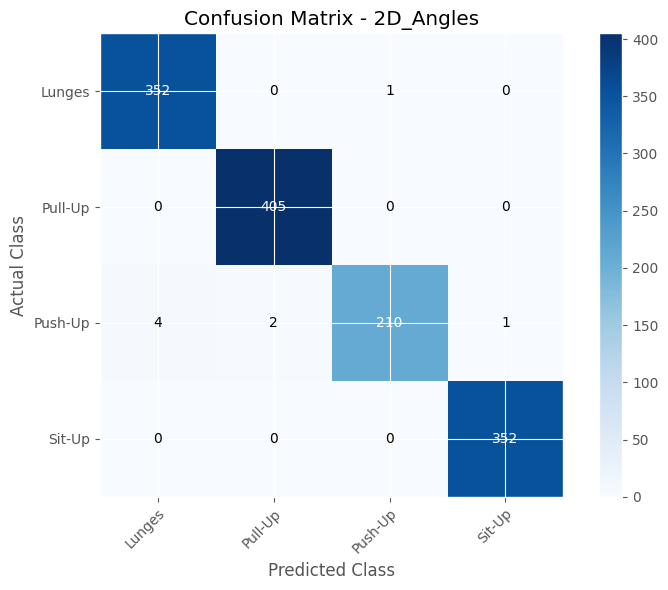


=== 3D_Angles ===


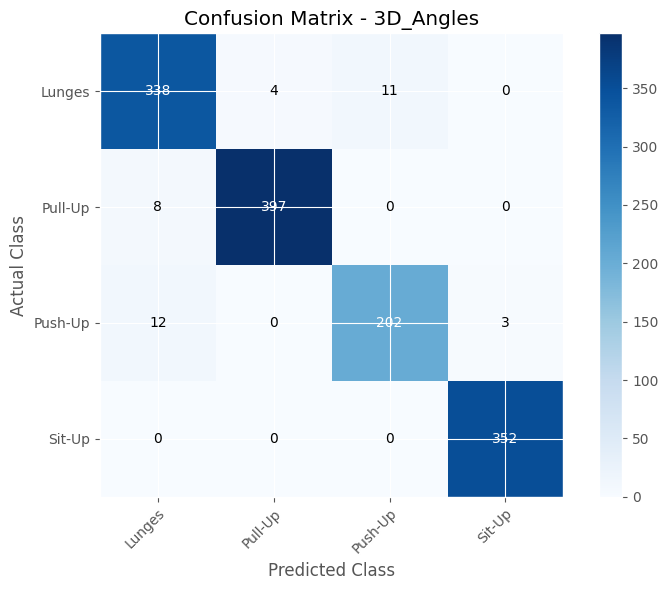


=== Torso_Angles ===


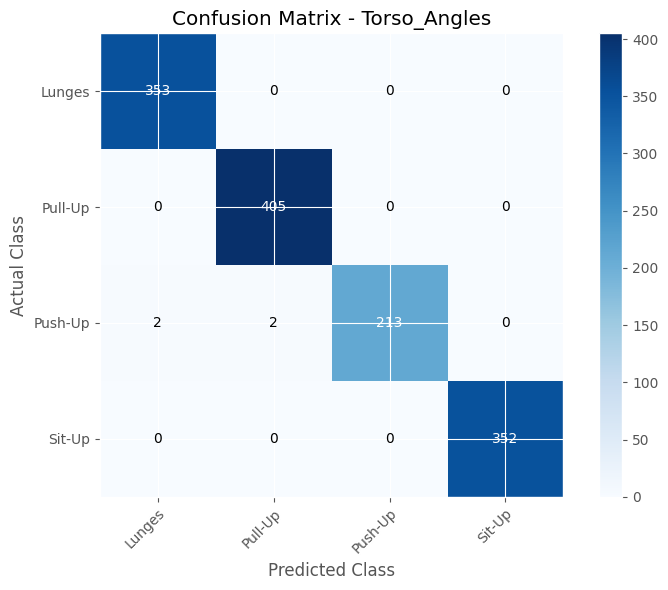


=== Batch_Size_8 ===


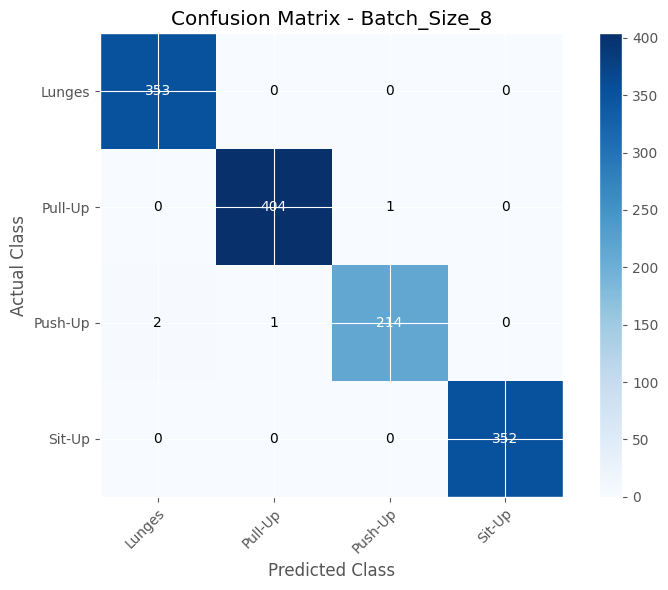


=== Batch_Size_16 ===


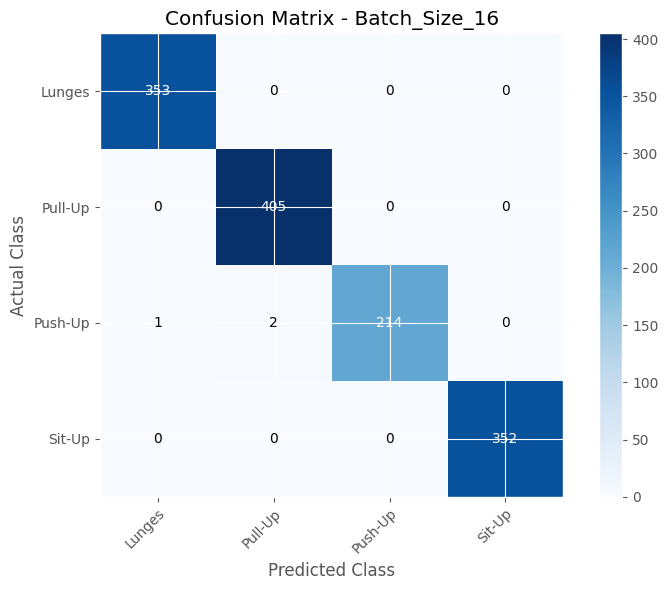


=== Learning_Rate_1e4 ===


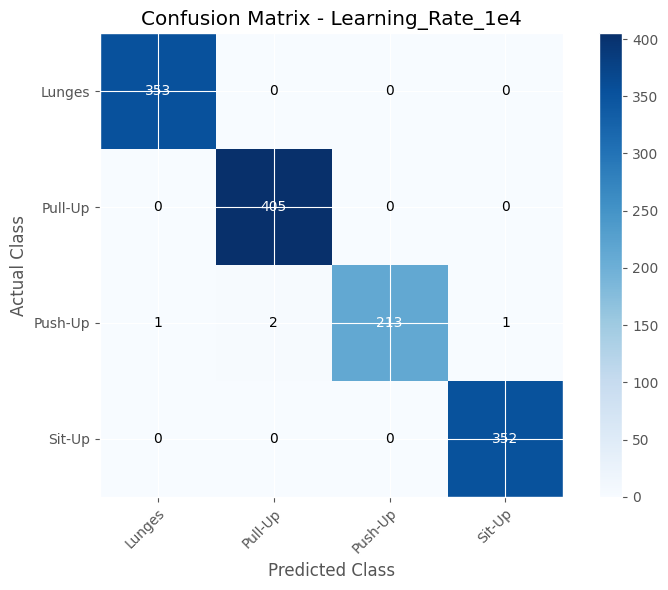


=== Learning_Rate_1e5 ===


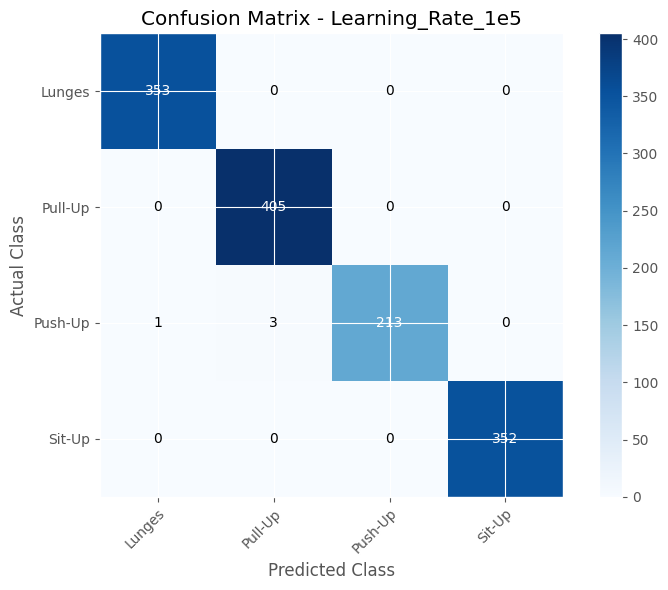


=== BiLSTM_Layer_2 ===


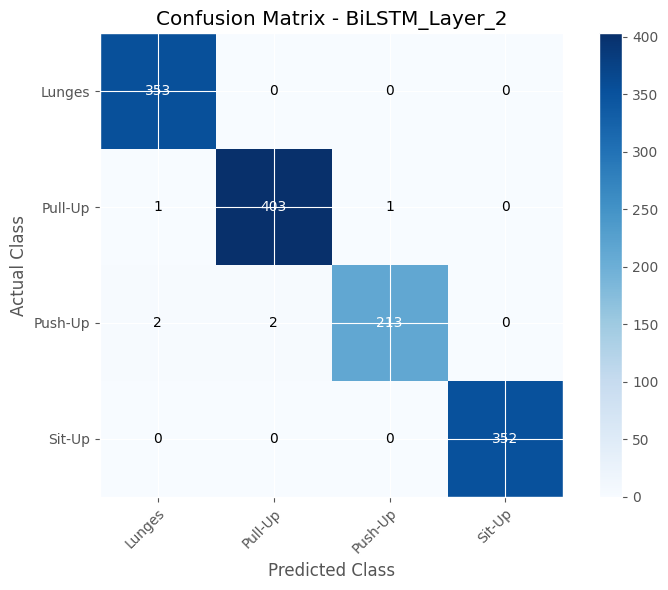

In [ ]:
# Show Confusion Matrix for Each Scenario

label_names = ["Lunges", "Pull-Up", "Push-Up", "Sit-Up"]

BASE_DIR = "/content/drive/MyDrive/X_Pose_Tracker/Result"

scenarios = [
    "2D_Angles",
    "3D_Angles",
    "Torso_Angles",
    "Batch_Size_8",
    "Batch_Size_16",
    "Learning_Rate_1e4",
    "Learning_Rate_1e5",
    "BiLSTM_Layer_2",
]

for scenario_name in scenarios:
    scenario_dir = os.path.join(BASE_DIR, scenario_name)

    cm = load_merged_confusion_matrix(
        scenario_dir,
        label_names
    )

    print(f"\n=== {scenario_name} ===")
    plot_confusion_matrix(
        cm,
        title=f"Confusion Matrix - {scenario_name}"
    )

## **Train Final Model**

In [ ]:
# Final Configuration For Final Model

BEST_HP = {
    "lstm_units": 64,
    "dropout_lstm": 0.4,
    "dense_units": 32,
    "dropout_dense": 0.4,
    "learning_rate": 1e-3
}

EPOCHS = 50
BATCH_SIZE = 16
PATIENCE = 10

In [ ]:
# Merge All Subject Function

def merge_subject_data(subject_Xy):
    X_list, y_list = [], []
    for _, (X_s, y_s) in subject_Xy.items():
        X_list.append(X_s)
        y_list.append(y_s)
    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    return X_all, y_all

In [ ]:
# Build Final Model LSTM

def build_final_bilstm(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # BiLSTM layer
        layers.Bidirectional(
            layers.LSTM(
                units=BEST_HP["lstm_units"],
                return_sequences=False
            )
        ),
        layers.Dropout(BEST_HP["dropout_lstm"]),

        # Dense Layer
        layers.Dense(
            BEST_HP["dense_units"],
            activation="relu"
        ),
        layers.Dropout(BEST_HP["dropout_dense"]),

        # Output Layer
        layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=BEST_HP["learning_rate"]
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Run Train Model

def train_final_model_loso_style(
    subject_Xy,
    le,
    val_subject,
    save_dir
):
    os.makedirs(save_dir, exist_ok=True)

    subjects = list(subject_Xy.keys())
    num_classes = len(le.classes_)

    # Split Dataset (Train and Val)
    train_subjects = [s for s in subjects if s != val_subject]

    X_train, y_train = concat_subjects(subject_Xy, train_subjects)
    X_val,   y_val   = subject_Xy[val_subject]

    print("Train subjects:", train_subjects)
    print("Val subject   :", val_subject)

    # Undersampling Train Dataset
    X_train, y_train = undersample_per_class_mean(
        X_train,
        y_train,
        min_cap=250,
        round_to=10,
        random_state=42
    )

    # Encoding Label (One-Hot Encoder)
    y_train_oh = keras.utils.to_categorical(y_train, num_classes)
    y_val_oh   = keras.utils.to_categorical(y_val,   num_classes)

    # Standardization (Z-score)
    mean, std = fit_standardize_train_only(X_train)

    X_train = apply_standardize(X_train, mean, std)
    X_val   = apply_standardize(X_val,   mean, std)

    # SAVE μ, σ for implementation in Android
    np.save(os.path.join(save_dir, "zscore_mean.npy"), mean)
    np.save(os.path.join(save_dir, "zscore_std.npy"),  std)

    # Make Dataset for Model
    input_shape = X_train.shape[1:]
    train_ds = make_dataset(X_train, y_train_oh, BATCH_SIZE, training=True)
    val_ds   = make_dataset(X_val,   y_val_oh,   BATCH_SIZE, training=False)

    # Build Model
    model = build_final_bilstm(input_shape, num_classes)
    model.summary()

    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(save_dir, "final_model_best.keras"),
            monitor="val_loss",
            save_best_only=True
        )
    ]

    # Train Model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Save Final Model (keras)
    model.save(os.path.join(save_dir, "final_model.keras"))

    # Save Labels
    with open(os.path.join(save_dir, "labels.txt"), "w") as f:
        for lab in le.classes_:
            f.write(lab + "\n")

    # Save Meta Data
    meta = {
        "val_subject": val_subject,
        "input_shape": list(input_shape),
        "num_classes": num_classes,
        "best_hp": BEST_HP,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "labels": list(le.classes_)
    }
    with open(os.path.join(save_dir, "meta.json"), "w") as f:
        json.dump(meta, f, indent=2)

    print("Final model saved")
    return model, history

In [ ]:
# Display Learning Curve Function

def plot_learning_curve(history):
    hist = history.history

    # Ambil metric yang tersedia
    acc_key = "accuracy" if "accuracy" in hist else ("acc" if "acc" in hist else None)
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else ("val_acc" if "val_acc" in hist else None)

    epochs = range(1, len(hist["loss"]) + 1)

    # LOSS CURVE
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curve - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ACCURACY CURVE
    if acc_key and val_acc_key:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist[acc_key], label="Train Accuracy")
        plt.plot(epochs, hist[val_acc_key], label="Val Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Learning Curve - Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("History tidak memiliki metric accuracy, hanya loss yang ditampilkan.")

In [ ]:
# EXPORT TO TFLITE Function

def export_tflite_from_keras(model, out_path, use_select_tf_ops=False):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    if use_select_tf_ops:
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS
        ]

    tflite_model = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite_model)

    print("Saved TFLite:", out_path)

In [ ]:
# Train Final Model

save_dir = "/content/drive/MyDrive/X_Pose_Tracker/Final_Model/"
val_subject = "Geraldo Forland"

model, hist = train_final_model_loso_style(subject_Xy, le, val_subject, save_dir)

Train subjects: ['Muhammad Fajri', 'Muhammad Rifqi', 'Nur Alam', 'Muhammad Fadly', 'Febriansyah', 'Haykhal', 'Imam B']
Val subject   : Geraldo Forland


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,196 (172.64 KB)

 Trainable params: 44,196 (172.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.7900 - loss: 0.6916 - val_accuracy: 0.9924 - val_loss: 0.0281
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9940 - loss: 0.0511 - val_accuracy: 0.9924 - val_loss: 0.0220
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9985 - loss: 0.0166 - val_accuracy: 0.9924 - val_loss: 0.0110
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.9924 - val_loss: 0.0094
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9994 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 1.0000 - v

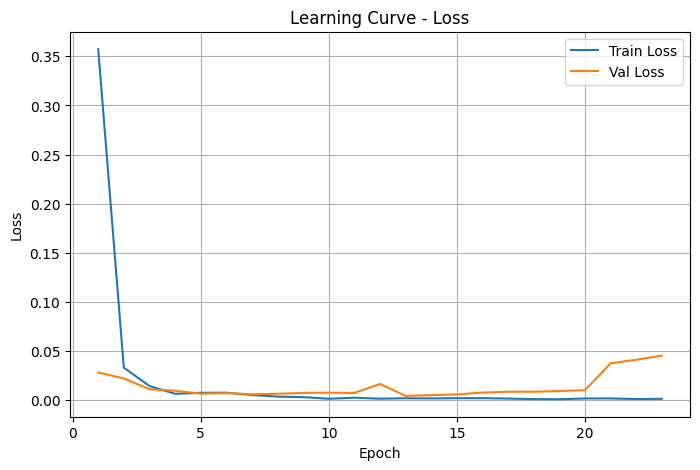

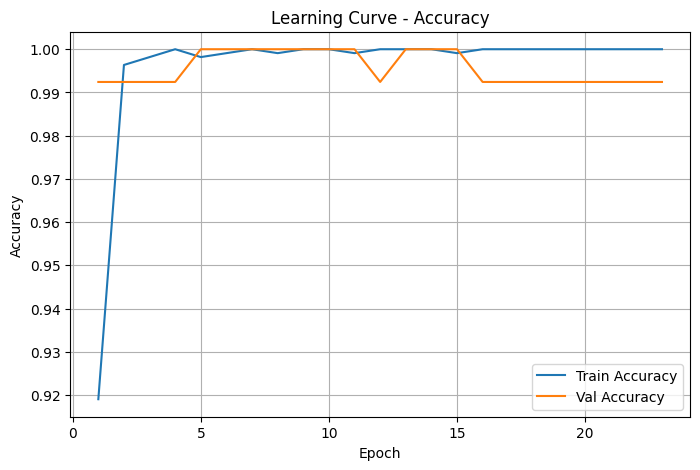

In [ ]:
plot_learning_curve(hist)

In [ ]:
# Export Model to TfLite Format

export_tflite_from_keras(model, os.path.join(save_dir, "Bilstm_model.tflite"), use_select_tf_ops=True)

Saved artifact at '/tmp/tmp1ja8_q7_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 13), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138779763067600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763066832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763068176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763069136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763067984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763066640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763068944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763069520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763069328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138779763065872: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TFLite: /con

## **Validasi Model TFLite**

In [ ]:
# Make Dataset to Validation Model TFLite and Keras

X_all = []
y_all = []

for s, (X_s, y_s) in subject_Xy.items():
      X_all.append(X_s)
      y_all.append(y_s)

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

In [ ]:
# Set Sample Data

N = 100
rng = np.random.default_rng(seed=42)
idx = rng.choice(len(X_all), size=N, replace=False)

X_sample = X_all[idx].astype(np.float32)
y_sample = y_all[idx]

In [ ]:
# Keras Model Prediction

y_keras = model.predict(X_sample, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
# TFLite Model Prediction Function

def tflite_predict_batch(tflite_path, X):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    preds = np.zeros((X.shape[0], output_details[0]["shape"][1]), dtype=np.float32)

    for i in range(X.shape[0]):
        interpreter.set_tensor(input_index, X[i:i+1])
        interpreter.invoke()
        preds[i] = interpreter.get_tensor(output_index)[0]

    return preds

In [ ]:
# Validation Keras and TFLite Model

tflite_path = "/content/drive/MyDrive/X_Pose_Tracker/Final_Model/Bilstm_model.tflite"
y_tflite = tflite_predict_batch(tflite_path, X_sample)

pred_keras = np.argmax(y_keras, axis=1)
pred_tflite = np.argmax(y_tflite, axis=1)

agreement = (pred_keras == pred_tflite).mean() * 100
print(f"Agreement (argmax): {agreement:.2f}%")

print("Keras preds:", pred_keras)
print("TFLite preds:", pred_tflite)

Agreement (argmax): 100.00%
Keras preds: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
TFLite preds: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
